In [ ]:
#| default_exp model_development.sn_pin_model

In [ ]:
#| hide
%load_ext autoreload
%autoreload 2

In [ ]:
#| export
from cv_tools.core import *
from cv_tools.imports import *
from fastprogress import progress_bar
import matplotlib.pyplot as plt
from datetime import datetime
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [ ]:
#| export
import torch.nn as nn
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from typing import List, Callable, Tuple, Dict
from collections import defaultdict
import monai

In [ ]:
#| export
from private_front_easy_pin_detection.model_development.wo_max_pool import *
from private_front_easy_pin_detection.dataloader_creation import *

In [ ]:
#| export
def split_ds(ds:Dataset, val_split:float=0.2):
    val_len = int(len(ds) * val_split)
    trn_ds = Subset(ds, indices=range(val_len))
    val_ds = Subset(ds, indices=range(val_len, len(ds)))
    return trn_ds, val_ds

In [ ]:
#| export
def get_dataloader(
    trn_im_path:str, 
    trn_msk_path:str,
    val_im_path:str,
    val_msk_path:str,
    trn_transform_func:str='get_training_augmentation',
    val_transform_func:str='get_validation_augmentation',
    tst_im_path:str=None,
    batch_size:int = 32,
    IMAGE_HEIGHT:int=128,
    IMAGE_WIDTH:int=128,
    num_workers:int=4   
    ):
    'Create dataloader with custom augmentation functions specified by name'
    
    # Get the function objects from their string names
    trn_transform_func = globals()[trn_transform_func]
    val_transform_func = globals()[val_transform_func]

    trn_transform = trn_transform_func(IMAGE_HEIGHT=IMAGE_HEIGHT, IMAGE_WIDTH=IMAGE_WIDTH)
    val_transform = val_transform_func(IMAGE_HEIGHT=IMAGE_HEIGHT, IMAGE_WIDTH=IMAGE_WIDTH)

    if val_im_path is None:
        trn_ds = PinSegmentationDataset(
            image_dir=trn_im_path, 
            mask_dir=trn_msk_path,
            transform=trn_transform)
        trn_ds, val_ds = split_ds(trn_ds, val_split=0.2)
        # changing the transforms for validation dataset
        val_ds.dataset.transform = val_transform
    else:
        trn_ds = PinSegmentationDataset(
            image_dir=trn_im_path, 
            mask_dir=trn_msk_path,
            transform=trn_transform)
        val_ds = PinSegmentationDataset(
            image_dir=val_im_path, 
            mask_dir=val_msk_path,
            transform=val_transform)

    if num_workers > 0:
        prefetch_factor = 2 
        persistent_workers = True
    else:
        prefetch_factor = None
        persistent_workers = False

    trn_dataloader = DataLoader(
        trn_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=persistent_workers,
        prefetch_factor=prefetch_factor
    )
    val_dataloader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=persistent_workers,
        prefetch_factor=prefetch_factor
    )
    if tst_im_path:
        tst_ds = InferenceDataset(tst_im_path, transform=val_transform)
        tst_dl = DataLoader(tst_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
        return trn_dataloader, val_dataloader, tst_dl
    else:
        return trn_dataloader, val_dataloader

In [ ]:
#| export
def get_training_augmentation(
    IMAGE_HEIGHT: int = 96,
    IMAGE_WIDTH: int = 96,

):
    train_transform = [
        A.RandomResizedCrop(height=IMAGE_HEIGHT, width=IMAGE_WIDTH, scale=(0.8, 1.0), ratio=(0.75, 1.33)),
        A.Perspective(p=0.3),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Rotate(limit=35, p=0.5),
        A.GaussNoise(var_limit=(.02, .005), p=0.3),  # Add Gaussian noise
        A.ElasticTransform(p=0.1, alpha=3, sigma=50 * 0.05),  # Removed alpha_affine parameter
        A.GridDistortion(p=0.1),
        A.OpticalDistortion(p=0.1, distort_limit=1, shift_limit=0.5),
        ToTensorV2(),
    ]
    return A.Compose(train_transform)

In [ ]:
#| export
def get_validation_augmentation(
    IMAGE_HEIGHT: int = 96,
    IMAGE_WIDTH: int = 96,

):
    train_transform = [
        A.RandomResizedCrop(height=IMAGE_HEIGHT, width=IMAGE_WIDTH, scale=(0.8, 1.0), ratio=(0.75, 1.33)),
        ToTensorV2(),
    ]
    return A.Compose(train_transform)

In [ ]:
trn_dl, val_dl = get_dataloader(
    trn_im_path=Path(trn_im_path),
    trn_msk_path=Path(trn_msk_path),
    val_im_path=Path(val_im_path),
    val_msk_path=Path(val_msk_path),
    batch_size=batch_size,
    num_workers=num_workers,
	trn_transform_func='get_training_augmentation',
    val_transform_func='get_validation_augmentation'
)

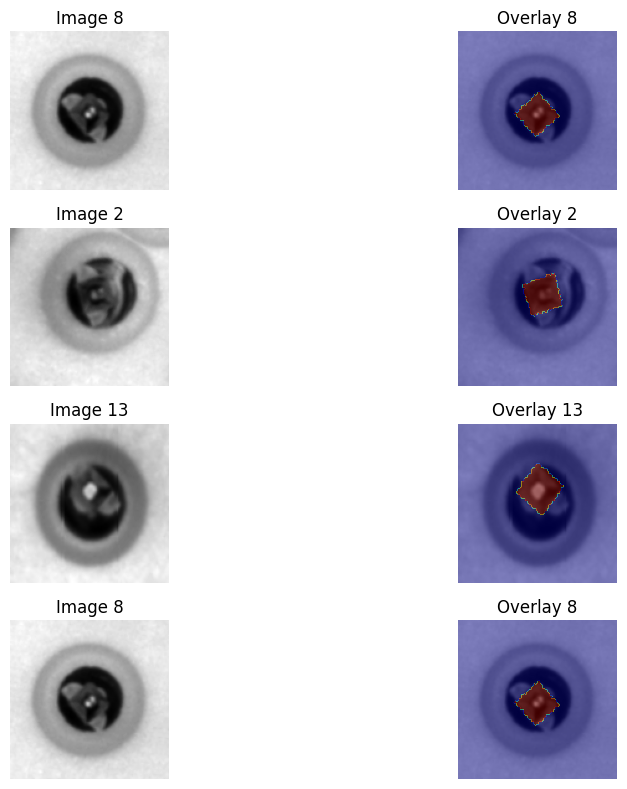

In [ ]:
show_batch(trn_dl)

In [ ]:
#| export
def calculate_foreground_iou(pred_mask, true_mask):
    """
    Calculate IoU for the foreground class (1) only.
    
    Args:
    pred_mask (torch.Tensor): Predicted mask with values between 0 and 1.
    true_mask (torch.Tensor): Ground truth mask with values 0 and 1.
    
    Returns:
    float: IoU for the foreground class.
    """
    # Ensure the masks are binary
    pred_mask = (pred_mask > 0.5).float()
    true_mask = (true_mask > 0.5).float()
    
    # Calculate intersection and union for foreground only
    intersection = torch.sum((pred_mask == 1) & (true_mask == 1))
    union = torch.sum((pred_mask == 1) | (true_mask == 1))
    
    # Compute IoU with smoothing to avoid division by zero
    iou = (intersection + 1e-6) / (union + 1e-6)
    
    return iou.item()

In [ ]:
#| export
def create_model(
        model_class:str='wo_max_pool',
        n_classes:int=1, 
        both_pool:bool=False
) -> nn.Module:
    "Create a model based on the specified class and parameters"
    if model_class == 'wo_max_pool':
        return UnetManualMaxPoolOnly(
            in_channels=1, 
            n_classes=n_classes,
            both_pool=both_pool
        )
    else:
        raise ValueError(f"Model class {model_class} not supported")

#| export

In [ ]:
def load_pretrained_model(
    model_path: Path, # including model filename .pth
    model_class: str = 'wo_max_pool',
    n_classes: int = 1,
    both_pool: bool = False
) -> nn.Module:
    """
    Load a pretrained model based on the specified model class.

    Args:
        model_path (Path): Path to the pretrained model weights.
        model_class (str, optional): Type of model to load. Defaults to 'wo_max_pool'.
        n_classes (int, optional): Number of output classes. Defaults to 1.
        both_pool (bool, optional): Whether to use both pooling types. Defaults to False.

    Returns:
        nn.Module: The loaded pretrained model.

    Raises:
        ValueError: If the specified model_class is not supported.
    """
    model_ = create_model(
        model_class=model_class,	
        n_classes=n_classes,
        both_pool=both_pool
        )
    checkpoint = torch.load(model_path)
    model_.load_state_dict(
        checkpoint['model_state_dict'])
    return model_

In [ ]:
trn_im_path = Path(r'//home/hasan/Schreibtisch/projects/data/easy_pin_detection/sn_img/trn_imgs_with_shapes')
trn_msk_path = Path(r'//home/hasan/Schreibtisch/projects/data/easy_pin_detection/sn_img/trn_msks_with_shapes')
val_im_path = Path(r'//home/hasan/Schreibtisch/projects/data/easy_pin_detection/sn_img/val_imgs_with_shapes')
val_msk_path = Path(r'//home/hasan/Schreibtisch/projects/data/easy_pin_detection/sn_img/val_msks_with_shapes')
batch_size = 16
num_workers = 0

In [ ]:

#| export
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss

        if self.reduction == 'mean':
            return torch.mean(focal_loss)
        elif self.reduction == 'sum':
            return torch.sum(focal_loss)
        else:
            return focal_loss

class TverskyFocalLoss(nn.Module):
    def __init__(self, alpha=0.5, beta=0.5, gamma=1, smooth=1e-6, reduction='mean'):
        super(TverskyFocalLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth
        self.reduction = reduction

    def forward(self, inputs, targets):
        inputs = torch.sigmoid(inputs)
        
        tp = torch.sum(inputs * targets, dim=(1, 2, 3))
        fp = torch.sum(inputs * (1 - targets), dim=(1, 2, 3))
        fn = torch.sum((1 - inputs) * targets, dim=(1, 2, 3))
        
        tversky = (tp + self.smooth) / (tp + self.alpha * fp + self.beta * fn + self.smooth)
        focal_tversky = (1 - tversky) ** self.gamma

        if self.reduction == 'mean':
            return torch.mean(focal_tversky)
        elif self.reduction == 'sum':
            return torch.sum(focal_tversky)
        else:
            return focal_tversky

# Example usage:
# criterion = FocalLoss()
# criterion = TverskyFocalLoss()

In [ ]:
model = create_model(
    model_class='wo_max_pool',
    n_classes=1,
    both_pool=False
)

In [ ]:
#| export
def to_item(x):
    "Convert `x` to Python number"
    return x.item() if isinstance(x, torch.Tensor) else x

In [ ]:
#| export
def validate(
        model: nn.Module, 
        dataloader: DataLoader, 
        loss_fn: nn.Module, 
        metrics: List[Callable], 
        threshold: float, 
        device: str
) -> Tuple[float, Dict[str, float]]:
    "Validate the `model` on `dataloader` using `loss_fn` and `metrics`"
    model.eval()
    val_losses, val_metrics = [], defaultdict(list)
    
    with torch.no_grad():
        for img, msk in dataloader:
            img, msk = img.float().to(device), msk.to(device)
            
            outputs = model(img)
            loss = loss_fn(outputs, msk)
            val_losses.append(loss.item())
            
            predicted_masks = (outputs > threshold).float()
            for metric in metrics:
                metric_name = metric.__name__ if callable(metric) else type(metric).__name__
                metric_value = metric(predicted_masks, msk)
                val_metrics[metric_name].append(to_item(metric_value))
    
    mean_val_loss = np.mean(val_losses)
    mean_val_metrics = {name: np.mean(values) for name, values in val_metrics.items()}
    
    return mean_val_loss, mean_val_metrics


In [ ]:
#| export

def train_batch(
        model: nn.Module, 
        batch: Tuple[torch.Tensor, torch.Tensor], 
        loss_fn: nn.Module, 
        optimizer: torch.optim.Optimizer, 
        device: str
) -> float:
    "Train the model on a single batch and return the loss"
    if device == 'cuda':
	    device = torch.device('cuda')
    img, msk = batch
    img, msk = img.float().to(device), msk.to(device)


    
    optimizer.zero_grad()
    outputs = model(img)
    loss = loss_fn(outputs, msk)
    loss.backward()
    optimizer.step()
    
    return loss.item()

def progress_bar(iterable, **kwargs):
    "Wrapper around fastprogress.progress_bar with default settings"
    return progress_bar(iterable,parents=None,  **kwargs)

In [ ]:
#| export
def train_batch(model, batch, loss_fn, optimizer, device):
    "Train the model on a single batch and return the loss"
    img, msk = batch
    img, msk = img.float().to(device), msk.to(device)
    
    optimizer.zero_grad()
    outputs = model(img)
    loss = loss_fn(outputs, msk)
    loss.backward()
    optimizer.step()
    
    return loss.item()

def to_device(x, device):
    "Move tensor(s) to chosen device"
    if isinstance(x, (list,tuple)): return [to_device(o, device) for o in x]
    return x.to(device, non_blocking=True)

def calculate_iou(pred, target, eps=1e-6):
    "Calculate IoU for binary segmentation"
    intersection = (pred & target).float().sum((1, 2))
    union = (pred | target).float().sum((1, 2))
    iou = (intersection + eps) / (union + eps)
    return iou.mean()

def validate(
        model: nn.Module, 
        dataloader: DataLoader, 
        loss_fn: nn.Module, 
        metrics: List[Callable], 
        threshold: float, 
        device: str
) -> Tuple[float, Dict[str, float]]:
    "Validate the `model` on `dataloader` using `loss_fn` and `metrics`"
    model.eval()
    val_losses, val_metrics = [], defaultdict(list)
    
    with torch.no_grad():
        for img, msk in dataloader:
            img, msk = img.float().to(device), msk.to(device)
            
            outputs = model(img)
            loss = loss_fn(outputs, msk)
            val_losses.append(loss.item())
            
            predicted_masks = (outputs > threshold).float()
            for metric in metrics:
                metric_name = metric.__name__ if callable(metric) else type(metric).__name__
                metric_value = metric(predicted_masks, msk)
                val_metrics[metric_name].append(metric_value.item() if isinstance(metric_value, torch.Tensor) else metric_value)
    
    mean_val_loss = np.mean(val_losses)
    mean_val_metrics = {name: np.mean(values) for name, values in val_metrics.items()}
    
    return mean_val_loss, mean_val_metrics


def train_model(
    model: nn.Module,
    train_dl: DataLoader,
    valid_dl: DataLoader,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler._LRScheduler,
    n_epochs: int,
    device: str,
    metrics: List[Callable],
    model_save_path: str,
    model_file_name: str
) -> Dict[str, List[float]]:
    "Train the model and return training history"
    history = defaultdict(list)
    best_valid_iou = 0.0
    best_epoch = 0

    for epoch in range(n_epochs):
        model.train()
        train_losses = []
        train_iou = []
        pbar = tqdm(train_dl, desc=f"Epoch {epoch+1}/{n_epochs}", leave=False)
        pbar.set_postfix({'Train Loss': 0.0, 'Train IoU': 0.0, 'Valid Loss': 0.0, 'Valid IoU': 0.0})
        for batch in pbar:
            loss = train_batch(model, batch, loss_fn, optimizer, device)
            train_losses.append(loss)
            # Calculate training IoU
            with torch.no_grad():
                img, msk = batch
                img, msk = img.to(device), msk.to(device)
                outputs = model(img)
                train_iou.append(calculate_foreground_iou(outputs, msk))
            pbar.set_postfix({'Train Loss': np.mean(train_losses), 'Train IoU': np.mean(train_iou)})
        
        valid_loss, valid_metrics = validate(
            model=model, 
            dataloader=valid_dl, 
            loss_fn=loss_fn, 
            metrics=metrics, 
            threshold=0.5, 
            device=device
        )
        scheduler.step(valid_loss)
        
        history['train_loss'].append(np.mean(train_losses))
        history['train_iou'].append(np.mean(train_iou))
        history['valid_loss'].append(valid_loss)
        for metric_name, metric_value in valid_metrics.items():
            history[f'valid_{metric_name}'].append(metric_value)
        
        val_metric = f'valid_{metrics[0].__name__}'
        print(val_metric)
        valid_iou = history[val_metric][-1]
        print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {history['train_loss'][-1]:.4f} - Train IoU: {history['train_iou'][-1]:.4f} - Valid Loss: {valid_loss:.4f} - Valid IoU: {valid_iou:.4f}")
        
        if valid_iou > best_valid_iou:
            best_valid_iou = valid_iou
            best_epoch = epoch + 1
            save_model(model, optimizer, best_epoch, best_valid_iou, model_save_path, model_file_name)

    print(f'\nTraining completed. Best validation IoU: {best_valid_iou:.4f} at epoch {best_epoch}')
    
    return history

def save_model(model, optimizer, epoch, best_valid_iou, model_save_path, model_file_name):
    "Save the model with best validation IoU"
    Path(model_save_path).mkdir(parents=True, exist_ok=True)
    current_time = datetime.now().strftime("%H_%M_%S")
    save_file_name = f"{model_file_name}_val_iou_{best_valid_iou:.4f}_epoch_{epoch}_{current_time}.pth"
    full_save_path = os.path.join(model_save_path, save_file_name)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_val_metric': best_valid_iou,
    }, full_save_path)
    print(f'New best model saved to {full_save_path}')

In [ ]:
#| export
def plot_training_history(history):
    "Plot training and validation metrics"
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['valid_loss'], label='Valid Loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['valid_calculate_foreground_iou'], label='Foreground IoU')
    #plt.plot(history['valid_background_iou'], label='Background IoU')
    plt.title('IoU over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('IoU')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
# | export

def end_to_end_training(
	train_transform_func:str,  # training augmentation from albumentations
    valid_transform_func:str,  # validation augmentation from albumentations
    train_im_path:Path, valid_im_path:Path,
    train_msk_path:Path, valid_msk_path:Path,
    model_cls:str,
    optimizer_cls:Callable, scheduler_cls:Callable,
	loss_fn:Callable,
	metrics:List[Callable],
	image_height:int=92, image_width:int=90,
    batch_size:int=16, num_workers:int=4, n_epochs:int=50,
    device:str='cuda', model_save_path:str='models',
    model_file_name:str='sn_pin_model', lr:float=1e-3
) -> Tuple[nn.Module, Dict[str, List[float]]]:
    "Run end-to-end training pipeline for SN-PIN model with fastai-style implementation"
    # Create dataloaders


    train_dl, valid_dl = get_dataloader(
        trn_im_path=train_im_path, trn_msk_path=train_msk_path,
        val_im_path=valid_im_path, val_msk_path=valid_msk_path,
        batch_size=batch_size, num_workers=num_workers,
        IMAGE_HEIGHT=image_height, IMAGE_WIDTH=image_width,
        trn_transform_func=train_transform_func,
        val_transform_func=valid_transform_func
    )

    model = create_model(
		model_class=model_cls,
		n_classes=1,
		both_pool=False
	)
    
    ## Initialize model and move to device
    model = model.to(device)
    
    ## Setup optimizer and scheduler
    optimizer = optimizer_cls(model.parameters(), lr=lr)
    scheduler = scheduler_cls(optimizer, T_0=10, T_mult=2)
    
    ## Define metrics
    
    # Train the model
    history = train_model(
      model=model,
      train_dl=train_dl,
      valid_dl=valid_dl,
      loss_fn=loss_fn,
      optimizer=optimizer,
      scheduler=scheduler,
      n_epochs=n_epochs,
      metrics=metrics,
      device=device,
      model_save_path=model_save_path,
      model_file_name=model_file_name
    )

    # Plot training history
    plot_training_history(history)

    return model, history

In [ ]:
model_save_path = Path('/home/hasan/Schreibtisch/projects/data/easy_pin_detection/sn_img/models')
model_file_name = 'sn_pin_model'

In [ ]:
model, history = end_to_end_training(
	model_cls='wo_max_pool',
    train_transform_func='get_training_augmentation',
    valid_transform_func='get_validation_augmentation',
    train_im_path=trn_im_path,
    train_msk_path=trn_msk_path,
    valid_im_path=val_im_path,
    valid_msk_path=val_msk_path,
	metrics=[calculate_foreground_iou],
    #loss_fn=FocalLoss(),
    loss_fn=monai.losses.TverskyLoss(include_background=True),
    optimizer_cls=torch.optim.AdamW,
    scheduler_cls=torch.optim.lr_scheduler.CosineAnnealingWarmRestarts,
	device='cuda',
    image_height=96, image_width=96,
	num_workers=0,
	lr=0.02,
    batch_size=100, 
	model_save_path=model_save_path,
    model_file_name=model_file_name,
    n_epochs=200
)

Epoch 1/200:   0%|          | 0/8 [00:00<?, ?it/s]

valid_calculate_foreground_iou
Epoch 1/200 - Train Loss: 0.8392 - Train IoU: 0.1975 - Valid Loss: 0.8825 - Valid IoU: 0.1072
New best model saved to /home/hasan/Schreibtisch/projects/data/easy_pin_detection/sn_img/models/sn_pin_model_val_iou_0.1072_epoch_1_06_59_19.pth


Epoch 2/200:   0%|          | 0/8 [00:00<?, ?it/s]

valid_calculate_foreground_iou
Epoch 2/200 - Train Loss: 0.7138 - Train IoU: 0.2491 - Valid Loss: 0.7522 - Valid IoU: 0.2780
New best model saved to /home/hasan/Schreibtisch/projects/data/easy_pin_detection/sn_img/models/sn_pin_model_val_iou_0.2780_epoch_2_06_59_21.pth


Epoch 3/200:   0%|          | 0/8 [00:00<?, ?it/s]

...

Epoch 13/200:   0%|          | 0/8 [00:00<?, ?it/s]

valid_calculate_foreground_iou
Epoch 13/200 - Train Loss: 0.1805 - Train IoU: 0.6972 - Valid Loss: 0.2179 - Valid IoU: 0.6382
New best model saved to /home/hasan/Schreibtisch/projects/data/easy_pin_detection/sn_img/models/sn_pin_model_val_iou_0.6382_epoch_13_06_59_36.pth


Epoch 14/200:   0%|          | 0/8 [00:00<?, ?it/s]

valid_calculate_foreground_iou
Epoch 14/200 - Train Loss: 0.1736 - Train IoU: 0.7068 - Valid Loss: 0.2161 - Valid IoU: 0.6440
New best model saved to /home/hasan/Schreibtisch/projects/data/easy_pin_detection/sn_img/models/sn_pin_model_val_iou_0.6440_epoch_14_06_59_38.pth


Epoch 15/200:   0%|          | 0/8 [00:00<?, ?it/s]

In [ ]:
#| export
# Visualize some random samples from the dataloader
def show_batch(dl, n=4, figsize=(12,8)):
    "Show a few random samples from a dataloader with overlaid masks"
    if isinstance(dl, torch.utils.data.DataLoader):
        batch = next(iter(dl))
    else:
        batch = dl
    
    imgs, msks = batch
    
    fig, axs = plt.subplots(n, 2, figsize=figsize)
    for i in range(n):
        idx = random.randint(0, len(imgs)-1)
        img = imgs[idx].permute(1,2,0).cpu().numpy()
        msk = msks[idx].squeeze().cpu().numpy()
        
        axs[i,0].imshow(img, cmap='gray')
        axs[i,0].set_title(f'Image {idx}')
        axs[i,0].axis('off')
        
        axs[i,1].imshow(img, cmap='gray')
        axs[i,1].imshow(msk, alpha=0.5, cmap='jet')
        axs[i,1].set_title(f'Overlay {idx}')
        axs[i,1].axis('off')
    
    plt.tight_layout()
    plt.show()

In [ ]:

# Visualize samples from training dataloader
print("Training samples:")
show_batch(trn_dl)

Training samples:


TypeError: get_training_augmentation() got an unexpected keyword argument 'image'

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export('36_model_development.sn_pin_model.ipynb')